# 🧠 Section 05. 전이학습 (Transfer Learning)
## CNN 구조와 영상 데이터 처리 실습

---
### 📌 이 노트북에서 배우는 것
- Oxford 102 Flowers 데이터셋을 탐색하고 클래스 분포를 확인한다
- Feature Extraction 방식으로 전이학습을 수행한다
- Fine-tuning 방식으로 전이학습을 수행하고 성능을 비교한다
- Backbone 동결·해제 및 Layer-wise Learning Rate를 적용한다

### 📦 사용 데이터셋
| 항목 | 내용 |
|------|------|
| 이름 | Oxford 102 Flowers |
| 크기 | 8,189장 |
| 클래스 | 102개 (꽃 종류) |
| 출처 | `torchvision.datasets.Flowers102` |

## ⚙️ 실습 전 필수 확인 — 로컬 환경 설정

이 노트북은 `environment.yml`로 생성한 가상환경에서 실행합니다.

**환경이 아직 설정되지 않았다면:**
```bash
conda env create -f environment.yml
conda activate cnn-course
```

**Jupyter Lab 실행:**
```bash
jupyter lab
```

> GPU가 있는 경우 자동으로 CUDA를 사용합니다. CPU만 있어도 실습에 지장 없습니다.

In [1]:
# ⚙️ 환경 설정 (반드시 가장 먼저 실행하세요)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 사용 디바이스: {device}")
print(f"✅ PyTorch: {torch.__version__}")
from torchvision.datasets import Flowers102
from torchvision import models
from torch.utils.data import DataLoader
print(f"✅ torchvision: {torchvision.__version__}")

✅ 사용 디바이스: cpu
✅ PyTorch: 2.11.0+cpu
✅ torchvision: 0.26.0+cpu


In [2]:
# ✅ 로컬 방식
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

nanum_fonts = [f for f in fm.fontManager.ttflist if 'Nanum' in f.name]

if nanum_fonts:
    font_path = nanum_fonts[0].fname          # 폰트 파일 경로 추출
    font_name = fm.FontProperties(fname=font_path).get_name()  # 실제 등록 이름 확인
    plt.rcParams['font.family'] = font_name
    print(f"✅ 적용 폰트: {font_name}")
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    print("⚠️ 나눔 폰트 없음 → 맑은 고딕 적용")

plt.rcParams['axes.unicode_minus'] = False

⚠️ 나눔 폰트 없음 → 맑은 고딕 적용


## 📁 Oxford 102 Flowers 소개

102종의 꽃 이미지 데이터셋입니다. 클래스당 샘플 수가 적어 전이학습의 필요성을 체감하기에 적합합니다.

| 항목 | 내용 |
|------|------|
| 총 이미지 수 | 8,189장 |
| 클래스 수 | 102개 |
| 훈련 세트 | 1,020장 (클래스당 10장) |
| 검증 세트 | 1,020장 |
| 테스트 세트 | 6,149장 |

> 클래스당 훈련 데이터가 **단 10장**입니다 → 처음부터 학습(From Scratch)은 거의 불가능합니다.

---
## 실습 1. 데이터셋 탐색

Oxford 102 Flowers는 전이학습의 필요성을 체감하기에 최적의 데이터셋입니다.

### 📖 이 데이터셋이 까다로운 이유

| 항목 | 내용 | 문제점 |
|---|---|---|
| 클래스당 훈련 이미지 | **단 10장** | 처음부터 학습(Scratch)이 사실상 불가 |
| 클래스 수 | 102개 | 많은 클래스, 적은 데이터 |
| 클래스 간 유사도 | 매우 높음 | 비슷하게 생긴 꽃이 많음 |

> 💡 **핵심 직관**  
> "102종의 꽃을 각 10장씩 보고 구분하라"는 요청입니다.  
> 사람도 어렵습니다. 딥러닝 모델이 처음부터 이걸 학습하는 건 더욱 어렵습니다.  
> 하지만 ImageNet으로 사전학습된 모델은 이미 "꽃의 질감·색상·형태"를 압니다.  
> 그 위에서 "어떤 꽃인지"만 배우면 됩니다 → 이것이 전이학습입니다.

In [3]:
# ─────────────────────────────────────────────
# 1-1. 데이터셋 로드
# ─────────────────────────────────────────────
IMG_SIZE = 224
MEAN = (0.485, 0.456, 0.406)   # ImageNet 통계
STD  = (0.229, 0.224, 0.225)

transform_train = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])
transform_val = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

train_set = Flowers102('./data', split='train', download=True, transform=transform_train)
val_set   = Flowers102('./data', split='val',   download=True, transform=transform_val)
test_set  = Flowers102('./data', split='test',  download=True, transform=transform_val)

print(f"훈련: {len(train_set)} / 검증: {len(val_set)} / 테스트: {len(test_set)}")

BATCH_SIZE = 32
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

100.0%
100.0%
100.0%


훈련: 1020 / 검증: 1020 / 테스트: 6149


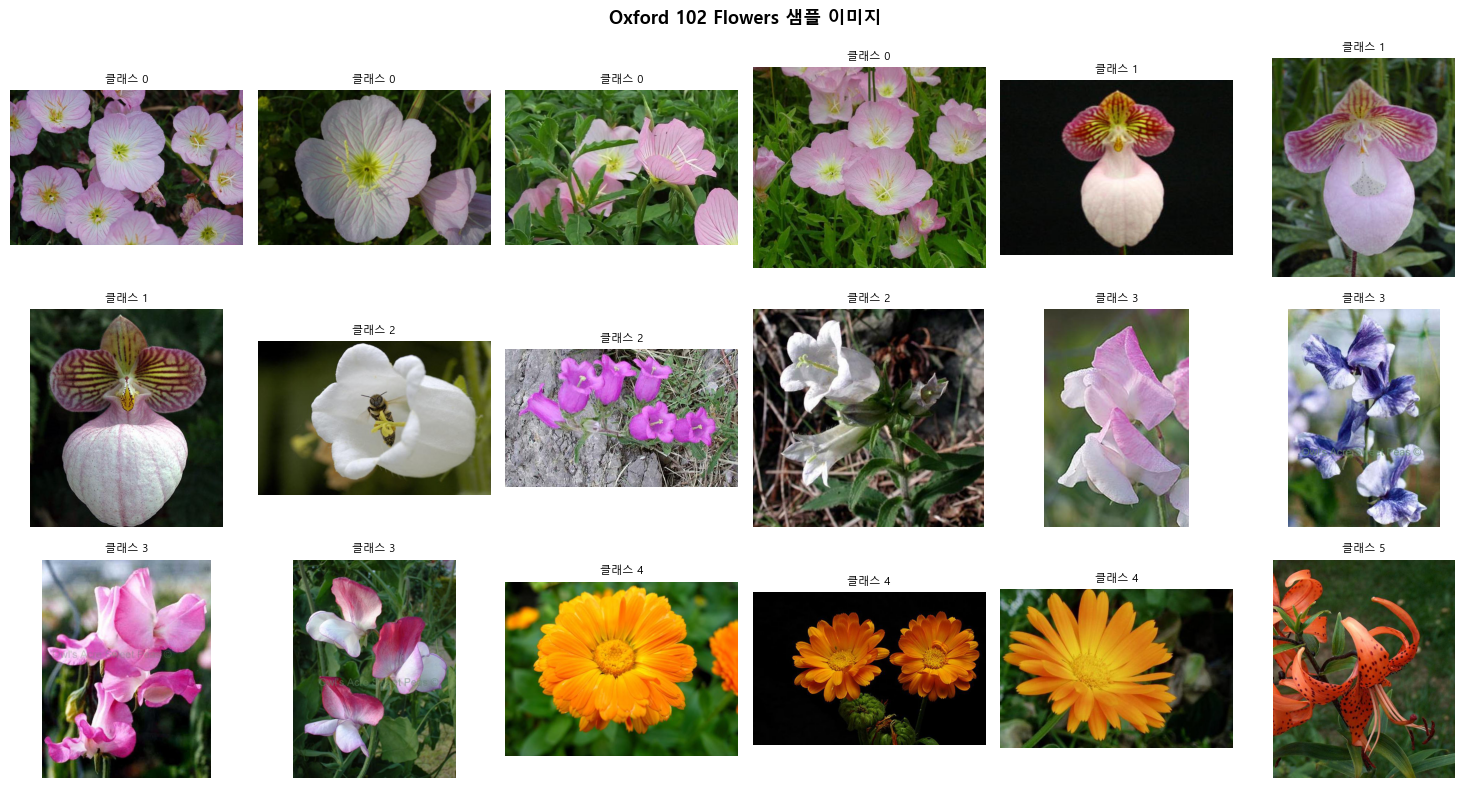

In [4]:
# ─────────────────────────────────────────────
# 1-2. 샘플 시각화
# ─────────────────────────────────────────────
train_raw = Flowers102('./data', split='train', download=True, transform=transforms.ToTensor())

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for idx, ax in enumerate(axes.ravel()):
    img, label = train_raw[idx * 3]
    ax.imshow(img.permute(1,2,0).clamp(0,1))
    ax.set_title(f"클래스 {label}", fontsize=8)
    ax.axis('off')
plt.suptitle("Oxford 102 Flowers 샘플 이미지", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 실습 2. Feature Extraction — Backbone 동결

### 📖 Feature Extraction이란?

사전학습된 모델의 Conv 레이어들(Backbone)은 이미 강력한 시각 특징을 추출합니다.  
이것을 그대로 "특징 추출기"로만 사용하고, 맨 마지막 분류 레이어(FC)만 교체합니다.

```
[기존 ResNet-50]
Conv 블록들 → ... → FC(2048→1000)  ← ImageNet 1000 클래스
               ↑
           모두 freeze (가중치 고정)

[Feature Extraction 버전]
Conv 블록들 → ... → FC(2048→102)   ← Flowers 102 클래스
               ↑               ↑
        freeze 유지         새로 학습
```

> 💡 **핵심 직관**  
> Backbone을 "뛰어난 눈을 가진 전문가"라고 생각하세요.  
> 그 전문가의 판단 능력(Conv 특징 추출)은 그대로 쓰고,  
> 최종 판정서(분류 헤드)만 꽃 102종용으로 바꿉니다.

> ⚠️ **주의**: `requires_grad=False`로 동결한 레이어는 `optimizer.step()`에서 업데이트되지 않습니다.  
> 따라서 optimizer에는 **학습 가능한 파라미터만** 전달해야 메모리와 속도가 효율적입니다.  
> `optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=...)`

### ✏️ TODO: Backbone 레이어 동결 코드 작성 및 분류 헤드 교체

In [ ]:
# ─────────────────────────────────────────────
# TODO: Feature Extraction 설정
# ─────────────────────────────────────────────

def build_feature_extractor(num_classes=102):
    """
    ResNet-50 기반 Feature Extractor.
    Backbone 전체를 동결하고 FC 레이어만 새로 교체한다.

    Args:
        num_classes (int): 분류할 클래스 수

    Returns:
        nn.Module: 수정된 모델
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # ① Backbone 레이어 전체 동결 (fc 레이어 제외)
    for param in model.___(  ):    # 힌트: 모델의 모든 파라미터를 순회하는 메서드
        param.requires_grad = ___  # 힌트: 그래디언트 계산을 비활성화 (False)

    # ② 분류 헤드 교체 (in_features는 그대로 유지)
    in_features = model.fc.in_features  # ResNet50 = 2048
    model.fc = nn.___(in_features, num_classes)
    # 힌트: 완전 연결 레이어(Linear)로 교체

    return model

model_fe = build_feature_extractor().to(device)

# 학습 가능 파라미터 확인
trainable = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_fe.parameters())
print(f"학습 가능 파라미터: {trainable:,} / 전체: {total:,} ({trainable/total*100:.1f}%)")

In [5]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------

def build_feature_extractor(num_classes=102):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False       # Backbone 전체 동결
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)  # 헤드 교체
    return model

model_fe = build_feature_extractor().to(device)
trainable = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_fe.parameters())
print(f"✅ 학습 파라미터: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\A/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100.0%


✅ 학습 파라미터: 208,998 / 23,717,030 (0.9%)


In [6]:
# ─────────────────────────────────────────────
# 2-1. Feature Extraction 학습
# ─────────────────────────────────────────────
def train_model(model, train_loader, val_loader, epochs, lr, name=""):
    """모델을 학습하고 history를 반환한다."""
    # FC 레이어만 학습하거나 전체 학습하도록 구분
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(params, lr=lr)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    hist = {"train_loss":[], "val_acc":[]}

    for epoch in range(1, epochs+1):
        model.train()
        tl, correct, total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward(); optimizer.step()
            tl += loss.item()
            correct += model(imgs).argmax(1).eq(labels).sum().item()
            total += labels.size(0)
        scheduler.step()

        model.eval(); vc, vt = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                vc += model(imgs).argmax(1).eq(labels).sum().item()
                vt += labels.size(0)
        hist["train_loss"].append(tl/len(train_loader))
        hist["val_acc"].append(vc/vt)
        if epoch % 3 == 0:
            print(f"[{name}] Epoch {epoch:2d} | Val Acc: {vc/vt*100:.2f}%")
    return hist

print("=== Feature Extraction 학습 (FC만 학습) ===")
hist_fe = train_model(model_fe, train_loader, val_loader, epochs=10, lr=1e-3, name="FE")

=== Feature Extraction 학습 (FC만 학습) ===
[FE] Epoch  3 | Val Acc: 63.63%
[FE] Epoch  6 | Val Acc: 84.02%
[FE] Epoch  9 | Val Acc: 86.37%


---
## 실습 3. Fine-tuning — 전체 레이어 학습

### 📖 Feature Extraction과의 차이

| 항목 | Feature Extraction | Fine-tuning |
|---|---|---|
| 학습하는 레이어 | FC만 | **전체** |
| 학습률 | 크게 써도 됨 | 반드시 **작게** (1e-4 이하) |
| 에포크 | 적게 | 더 많이 |
| 성능 | 빠르게 괜찮은 결과 | 더 높은 최종 성능 |

### 📖 왜 Fine-tuning 시 학습률을 작게 써야 하는가?

> 💡 **핵심 직관**  
> 사전학습된 가중치는 오랜 학습으로 좋은 상태입니다.  
> 학습률이 크면 이 좋은 가중치를 순식간에 "덮어씁니다."  
> 작은 학습률로 천천히 조금씩 새 데이터에 맞게 조정하는 것이 핵심입니다.

### 📖 Layer-wise Learning Rate

앞쪽 레이어(저수준 특징: 엣지, 텍스처)는 거의 바꿀 필요가 없습니다.  
뒤쪽 레이어(고수준 특징: 꽃 모양)는 더 적극적으로 학습해야 합니다.

```python
# 개념 설명
optimizer = optim.Adam([
    {"params": model.layer1.parameters(), "lr": 1e-5},  # 앞 → 작은 lr
    {"params": model.layer4.parameters(), "lr": 1e-4},  # 뒤 → 큰 lr
    {"params": model.fc.parameters(),     "lr": 1e-3},  # FC → 가장 큰 lr
])
```

> ⚠️ **주의**: `optimizer.zero_grad()`와 `optimizer.step()`은 여전히 필요합니다.  
> Fine-tuning이라도 학습 루프 4단계 순서는 동일합니다.

In [ ]:
# ─────────────────────────────────────────────
# 3-1. Fine-tuning 모델 설정 (Layer-wise LR)
# ─────────────────────────────────────────────
model_ft = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model_ft.fc = nn.Linear(model_ft.fc.in_features, 102)
model_ft = model_ft.to(device)

# Layer-wise Learning Rate: 초기 레이어는 작은 lr, 후기 레이어는 큰 lr
# ✏️ 빈칸: optimizer param_groups에 레이어별 학습률 설정
optimizer_ft = optim.Adam([
    {"params": model_ft.layer1.parameters(), "lr": ___},   # 힌트: 가장 작은 lr (예: 1e-5)
    {"params": model_ft.layer2.parameters(), "lr": 1e-5},
    {"params": model_ft.layer3.parameters(), "lr": 1e-4},
    {"params": model_ft.layer4.parameters(), "lr": 1e-4},
    {"params": model_ft.fc.parameters(),     "lr": 1e-3},  # FC는 가장 큰 lr
])
print("Fine-tuning optimizer 설정:")
for i, pg in enumerate(optimizer_ft.param_groups):
    print(f"  group {i}: lr={pg['lr']}")

Fine-tuning optimizer 설정:
  group 0: lr=1e-05
  group 1: lr=1e-05
  group 2: lr=0.0001
  group 3: lr=0.0001
  group 4: lr=0.001


In [ ]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
# layer1의 lr = 1e-5 (backbone 앞 레이어는 ImageNet 특징 보존)
# 직관: 앞 레이어는 이미 좋은 특징(엣지 등)을 갖고 있어 크게 바꿀 필요 없음
print("layer1 lr = 1e-5")

In [10]:
# Fine-tuning 학습 (간이 버전 — 내부 optimizer 사용)
def train_finetune(model, optimizer, train_loader, val_loader, epochs):
    """Layer-wise LR로 Fine-tuning 학습."""
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
    hist = {"train_loss":[], "val_acc":[]}
    for epoch in range(1, epochs+1):
        model.train()
        tl = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward(); optimizer.step()
            tl += loss.item()
        scheduler.step()
        model.eval(); vc, vt = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                vc += model(imgs).argmax(1).eq(labels).sum().item()
                vt += labels.size(0)
        hist["train_loss"].append(tl/len(train_loader))
        hist["val_acc"].append(vc/vt)
        if epoch % 3 == 0:
            print(f"[FT] Epoch {epoch:2d} | Val Acc: {vc/vt*100:.2f}%")
    return hist

print("=== Fine-tuning 학습 ===")
hist_ft = train_finetune(model_ft, optimizer_ft, train_loader, val_loader, epochs=10)

=== Fine-tuning 학습 ===
[FT] Epoch  3 | Val Acc: 85.49%
[FT] Epoch  6 | Val Acc: 92.65%
[FT] Epoch  9 | Val Acc: 93.43%


---
## 실습 4. 3가지 방식 성능 비교

이번 실습의 핵심 비교입니다. 동일한 데이터에서 세 가지 전략의 성능 차이를 직접 확인합니다.

| 전략 | 초기화 | 학습 레이어 | 예상 성능 | 예상 학습 시간 |
|---|---|---|---|---|
| From Scratch | 랜덤 | 전체 | 낮음 (데이터 부족) | 김 |
| Feature Extraction | ImageNet | FC만 | 중간~높음 | 짧음 |
| Fine-tuning | ImageNet | 전체 | 가장 높음 | 중간 |

> 💡 **실제로 어떻게 선택하나요?**  
> 실무에서는 먼저 Feature Extraction으로 빠르게 기준 성능을 잡고,  
> 이후 Fine-tuning으로 성능을 끌어올리는 2단계 전략이 일반적입니다.

In [11]:
# ─────────────────────────────────────────────
# 4-1. From Scratch (기준선)
# ─────────────────────────────────────────────
class ScratchResNet(nn.Module):
    """전이학습 없이 처음부터 학습하는 ResNet-50 (기준선)."""
    def __init__(self):
        super().__init__()
        self.net = models.resnet50(weights=None)
        self.net.fc = nn.Linear(self.net.fc.in_features, 102)
    def forward(self, x): return self.net(x)

model_scratch = ScratchResNet().to(device)
print("=== From Scratch 학습 ===")
hist_scratch = train_model(model_scratch, train_loader, val_loader,
                            epochs=10, lr=1e-3, name="Scratch")

=== From Scratch 학습 ===
[Scratch] Epoch  3 | Val Acc: 3.24%
[Scratch] Epoch  6 | Val Acc: 8.04%
[Scratch] Epoch  9 | Val Acc: 15.49%


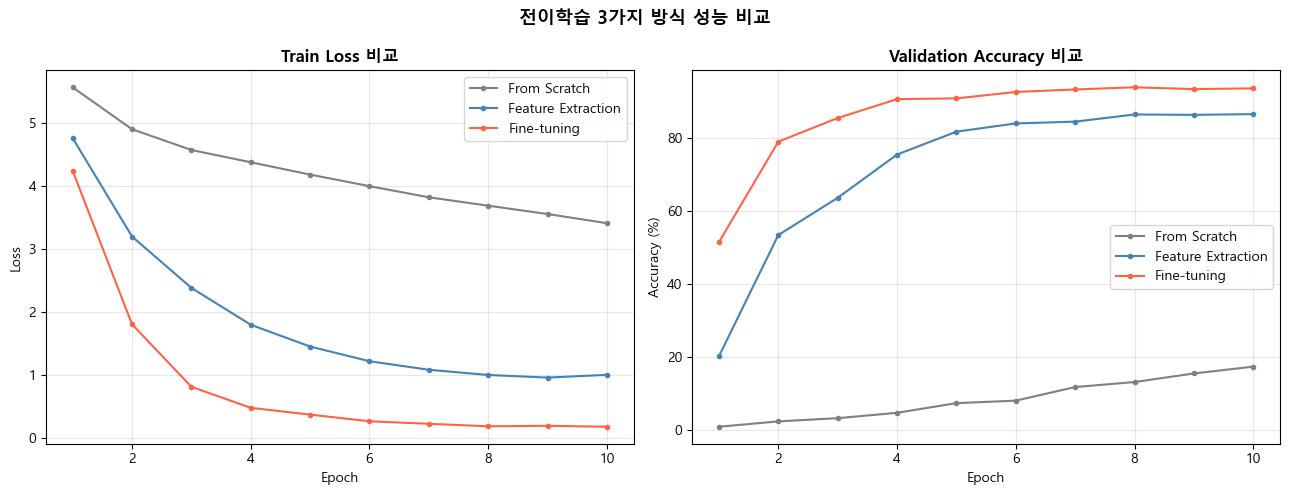

Scratch               : 최종 Val Acc = 17.35%
Feature Extraction    : 최종 Val Acc = 86.57%
Fine-tuning           : 최종 Val Acc = 93.63%


In [12]:
# ─────────────────────────────────────────────
# 4-2. 3가지 방식 비교 그래프
# ─────────────────────────────────────────────
epochs = range(1, 11)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for hist, name, color in [
    (hist_scratch, "From Scratch", 'gray'),
    (hist_fe,      "Feature Extraction", 'steelblue'),
    (hist_ft,      "Fine-tuning", 'tomato')
]:
    axes[0].plot(epochs, hist["train_loss"], color=color, marker='o', markersize=3, label=name)
    axes[1].plot(epochs, [a*100 for a in hist["val_acc"]], color=color, marker='o', markersize=3, label=name)

for ax, title, ylabel in [
    (axes[0], "Train Loss 비교", "Loss"),
    (axes[1], "Validation Accuracy 비교", "Accuracy (%)")
]:
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("전이학습 3가지 방식 성능 비교", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

for hist, name in [(hist_scratch,"Scratch"), (hist_fe,"Feature Extraction"), (hist_ft,"Fine-tuning")]:
    print(f"{name:<22}: 최종 Val Acc = {hist['val_acc'][-1]*100:.2f}%")

---
## 🚀 도전 과제

### 과제 1. 더 강력한 증강
`transforms.RandomGrayscale`, `transforms.RandomPerspective`를 추가하고 성능 변화를 확인하세요.

### 과제 2. EfficientNet 비교
`models.efficientnet_b0()`으로 동일한 Fine-tuning을 수행하고 ResNet-50과 비교하세요.

### 과제 3. Gradual Unfreezing
처음에는 FC만, 이후 layer4, layer3 순서로 epoch 단위로 해제하며 학습하는  
Gradual Unfreezing을 구현하세요.
